In [1]:
%matplotlib inline
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import os
import sys
matplotlib.rcParams['text.usetex'] = True

In [2]:
from classy import Class

In [3]:
# # If you need to work with seperate instances of CLASS

# class_path = '/afs/crc.nd.edu/user/s/sghosh5/class_public' # Path to your CLASS directory
# classy_path = ''
# for elem in os.listdir(os.path.join(
#         class_path, "python", "build")):
#     if elem.find("lib.") != -1:
#         classy_path = os.path.join(
#             class_path, "python", "build", elem)
#     if len(classy_path)==1:
#         classy_path = classy_path[0]
#     else:
#         stringcheck = "%i.%i"%(sys.version_info.major,sys.version_info.minor)
#         for path in classy_path:
#             if stringcheck in path:
#                 classy_path = path
#                 break

# # Inserting the previously found path into the list of folders to
# # search for python modules.
# sys.path.insert(1, classy_path)
# try:
#     from classy import Class
# except ImportError:
#     print('Error: Could not import Classy.')

    
# M = Class()
# sys.path.remove(classy_path)
# del Class
# del sys.modules['classy']

In [4]:
M = Class()

In [5]:
plt.rcParams['figure.dpi'] = 200

In [6]:
common_settings = {
                   'output':'mPk,lCl,pCl,tCl,mTk,dTk',
                   'h':0.67556,
                   'omega_b':0.02238280,   
                   'omega_cdm':0.1201075,  
                   'A_s':2.215e-9,
                   'n_s':0.9619,
                   'tau_reio':0.05430842,
                   'YHe':'BBN',
                   'l_max_scalars':2500,
                   'k_output_values': '0.01,0.1,1.0, 0.001',
                   'z_max_pk':100,
                   'P_k_max_1/Mpc':1.0,
                    'gauge':'newtonian',
                    'lensing':'yes'}

# Takes inputs in an dictionary form. Relevant inputs in: https://github.com/lesgourg/class_public/blob/master/explanatory.ini

In [7]:
M.empty()
M.set(common_settings) #Set parameters
M.compute() # Compute CLASS

In [8]:
# Reading output 
unlencl = M.raw_cl() # C_L (without l(l+1)/2\pi) factor
lencl = M.lensed_cl()
tran = M.get_transfer(z=0)
bckg = M.get_background()
pert = M.get_perturbations()

In [9]:
print(fr'Omega_m = {M.Omega_m()}')
print(fr'N_eff = {M.Neff()}')

Omega_m = 0.3122176472915082
N_eff = 3.0440000000000005


In [10]:
M.T_cmb()

2.7255

In [11]:
# The l(l+1)/(2pi) factor
unell=unlencl['ell'][2:]
unlfac=unell*(unell+1)/(2*np.pi)
lell=lencl['ell'][2:]
lfac=lell*(lell+1)/(2*np.pi)

In [12]:
lencl.keys()

dict_keys(['tt', 'ee', 'te', 'bb', 'pp', 'tp', 'ell'])

In [13]:
M.h()

0.67556

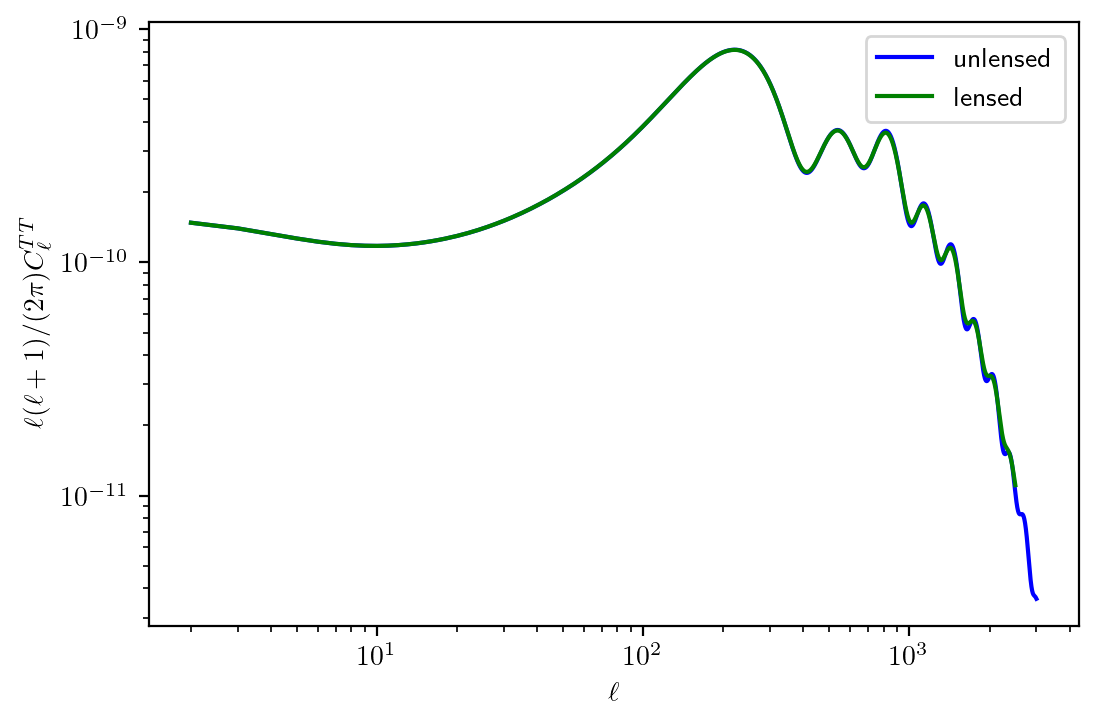

In [14]:
plt.semilogx(unlencl['ell'][2:],unlencl['tt'][2:]*unlfac, c='b',label='unlensed' )
plt.semilogx(lencl['ell'][2:],lencl['tt'][2:]*lfac, c='g', label='lensed' )
plt.xlabel('$\ell$')
plt.ylabel('$\ell(\ell + 1)/(2 \pi)C_\ell^{TT}$')
plt.legend()
plt.yscale('log')

In [15]:
# plt.plot(lencl['ell'][2:],lencl['tt'][2:]/ unlencl['tt'][2:len(lencl['ell'])] - 1, c='g', label='lensed/unlensed - 1' )
# plt.xlabel('$\ell$')
# plt.ylabel('$\Delta C_\ell^{TT} / C_\ell^{TT}$')
# plt.xscale('log')
# plt.yscale('log')
# plt.legend()

Text(0, 0.5, '$\\ell(\\ell + 1)/(2 \\pi)C_\\ell^{EE}$')

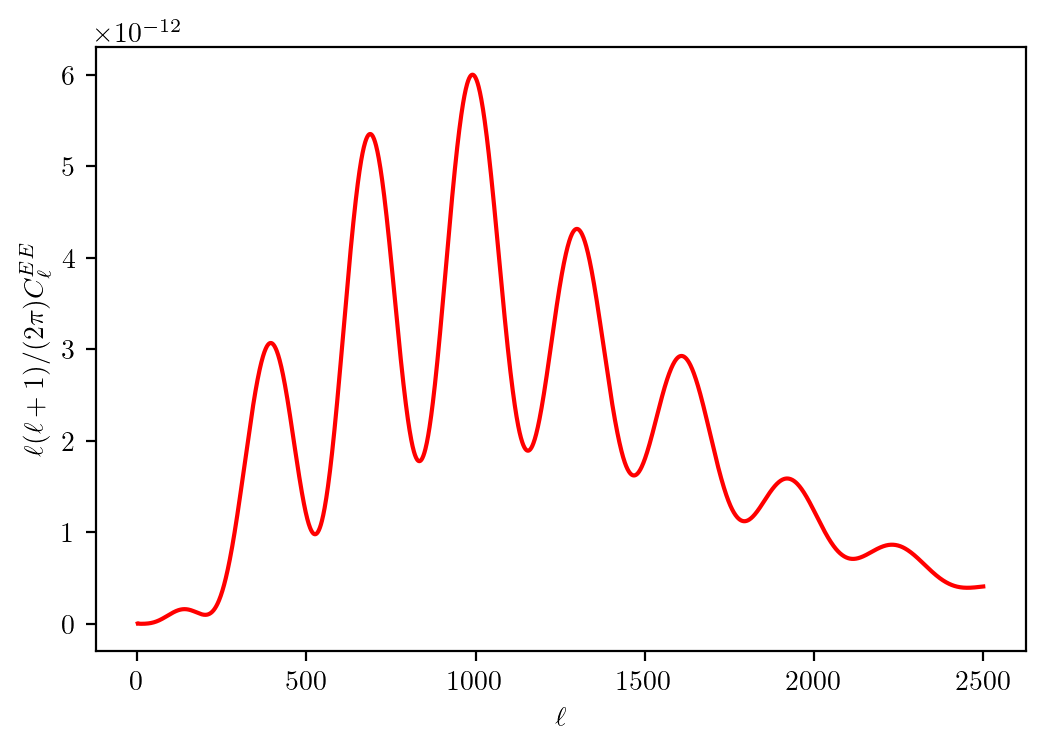

In [16]:
plt.plot(lencl['ell'][2:],lencl['ee'][2:]*lfac, c='r', label='EE' )
plt.xlabel('$\ell$')
plt.ylabel('$\ell(\ell + 1)/(2 \pi)C_\ell^{EE}$')

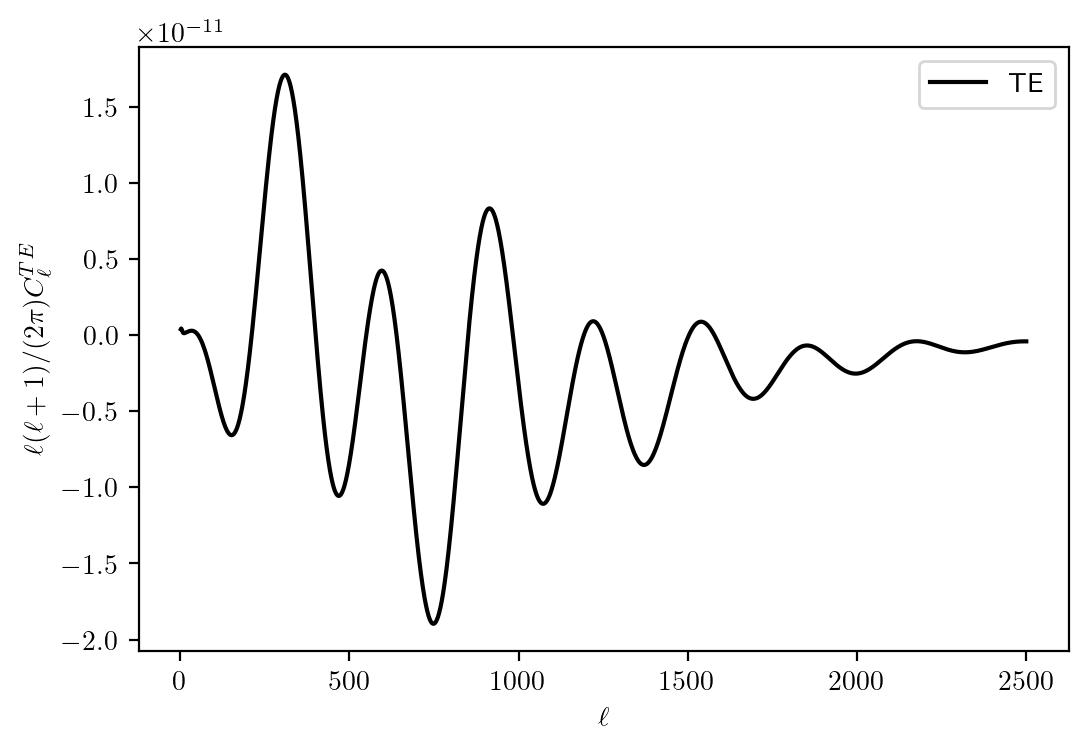

In [17]:
plt.plot(lencl['ell'][2:],lencl['te'][2:]*lfac, c='k', label='TE' )
plt.xlabel('$\ell$')
plt.ylabel('$\ell(\ell + 1)/(2 \pi)C_\ell^{TE}$')
plt.legend()

In [18]:
hval=M.h()
khvec = hval*np.logspace(-3,np.log10(1),1000) # array of kvec in h/Mpc
pk=np.asarray([M.pk(k,0) for k in khvec])/hval**3

Text(0, 0.5, '$ P({\\rm Mpc}/h)^3$')

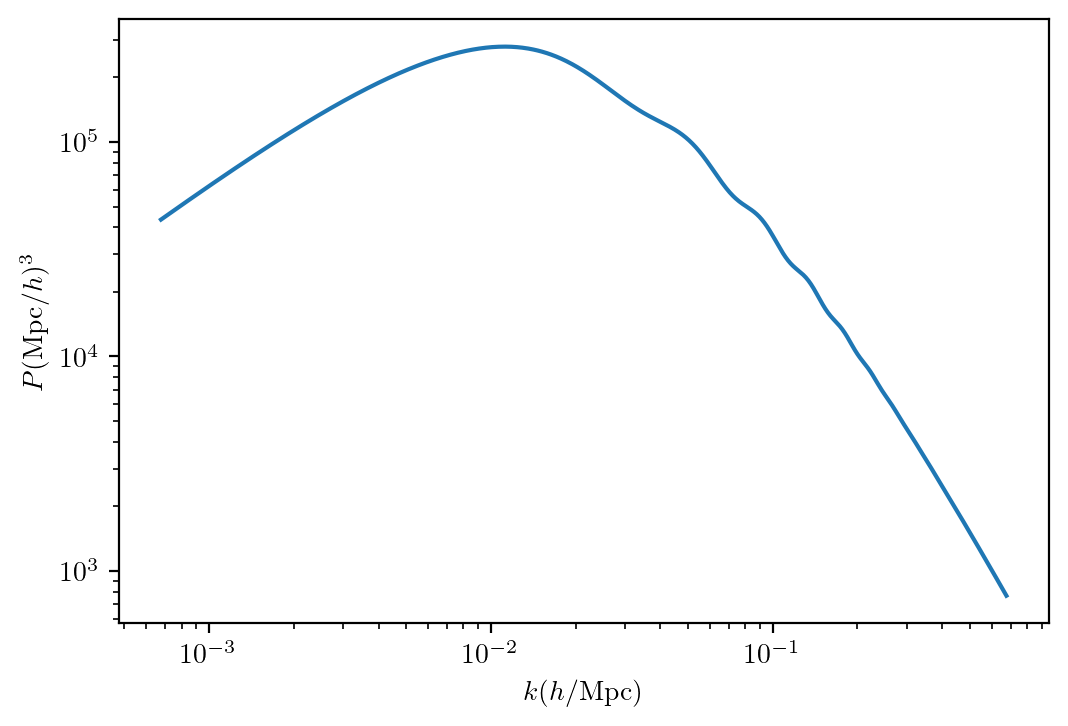

In [19]:
plt.plot(khvec,pk)
plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'$k(h/{ \rm Mpc})$')
plt.ylabel(r'$ P({\rm Mpc}/h)^3$')

In [20]:
bckg

{'z': array([1.00000000e+14, 9.89308584e+13, 9.78731474e+13, ...,
        2.17307062e-02, 1.08069579e-02, 0.00000000e+00]),
 'proper time [Gyr]': array([7.55951851e-26, 7.72379221e-26, 7.89163568e-26, ...,
        1.34836591e+01, 1.36380469e+01, 1.37932315e+01]),
 'conf. time [Mpc]': array([4.63478500e-09, 4.68571670e-09, 4.73664841e-09, ...,
        1.40660610e+04, 1.41141659e+04, 1.41620021e+04]),
 'H [1/Mpc]': array([2.15725629e+22, 2.11137463e+22, 2.06646880e+22, ...,
        2.27674939e-04, 2.26492947e-04, 2.25342560e-04]),
 'comov. dist.': array([14162.00213238, 14162.00213238, 14162.00213238, ...,
           95.94114159,    47.83624281,     0.        ]),
 'ang.diam.dist.': array([1.41620021e-10, 1.43150503e-10, 1.44697524e-10, ...,
        9.39006149e+01, 4.73248056e+01, 0.00000000e+00]),
 'lum. dist.': array([1.41620021e+18, 1.40105903e+18, 1.38607972e+18, ...,
        9.80260104e+01, 4.83532071e+01, 0.00000000e+00]),
 'comov.snd.hrz.': array([2.67631746e-09, 2.70524032e-09, 2.

Text(0, 0.5, 'conf. time [Mpc]')

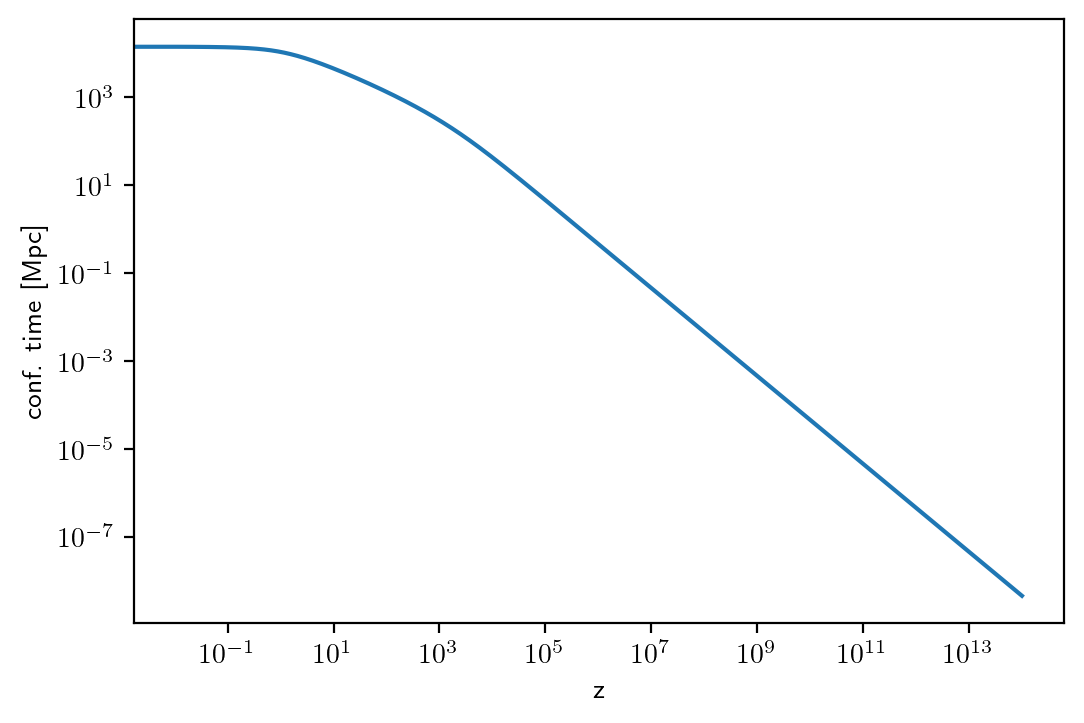

In [21]:
plt.loglog(bckg['z'],bckg['conf. time [Mpc]'] )
plt.xlabel('z')
plt.ylabel('conf. time [Mpc]')

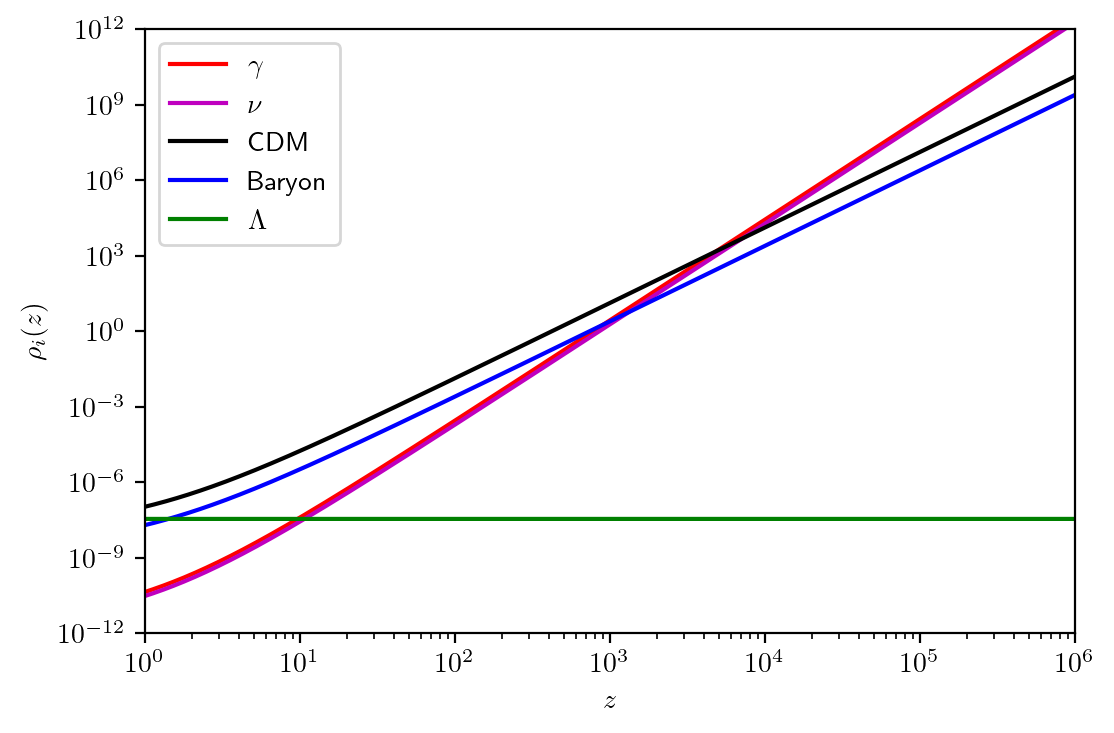

In [22]:
plt.loglog(bckg['z'],bckg['(.)rho_g'], c = 'r', label = r'$\gamma$' )
plt.loglog(bckg['z'],bckg['(.)rho_ur'], c = 'm', label = r'$\nu$' )
plt.loglog(bckg['z'],bckg['(.)rho_cdm'], c = 'k', label = r'CDM' )
plt.loglog(bckg['z'],bckg['(.)rho_b'], c = 'b', label = r'Baryon' )
plt.loglog(bckg['z'],bckg['(.)rho_lambda'], c = 'g', label = r'$\Lambda$' )
plt.xlabel(r'$z$')
plt.ylabel(r'$\rho_i(z)$')
plt.xlim([1,1e6])
plt.ylim([1e-12,1e12])
plt.legend()

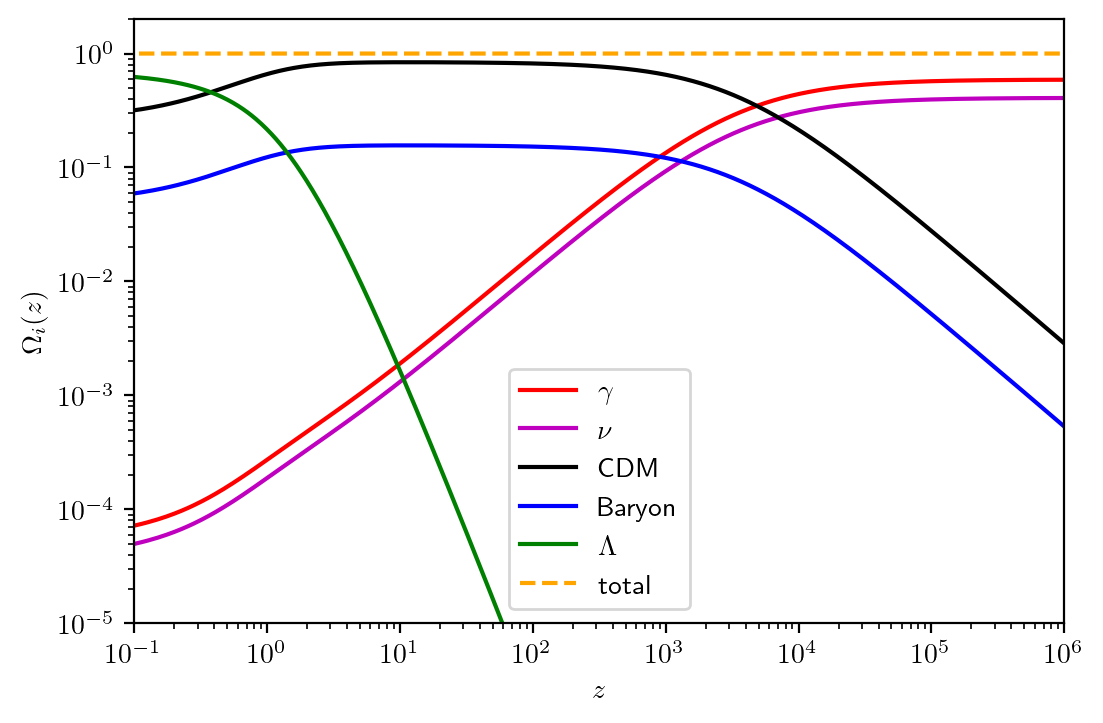

In [23]:
plt.loglog(bckg['z'],bckg['(.)rho_g']/bckg['(.)rho_crit'], c = 'r', label = r'$\gamma$' )
plt.loglog(bckg['z'],bckg['(.)rho_ur']/bckg['(.)rho_crit'], c = 'm', label = r'$\nu$' )
plt.loglog(bckg['z'],bckg['(.)rho_cdm']/bckg['(.)rho_crit'], c = 'k', label = r'CDM' )
plt.loglog(bckg['z'],bckg['(.)rho_b']/bckg['(.)rho_crit'], c = 'b', label = r'Baryon' )
plt.loglog(bckg['z'],bckg['(.)rho_lambda']/bckg['(.)rho_crit'], c = 'g', label = r'$\Lambda$' )
plt.loglog(bckg['z'],(bckg['(.)rho_g']+bckg['(.)rho_ur']+bckg['(.)rho_cdm']+bckg['(.)rho_b']+bckg['(.)rho_lambda'])/bckg['(.)rho_crit'], c = 'orange', label = r'total', ls ='--' )
plt.xlabel(r'$z$')
plt.ylabel(r'$\Omega_i(z)$')
plt.xlim([1e-1,1e6])
plt.ylim([1e-5,2])
plt.legend()


In [24]:
tran.keys()

dict_keys(['k (h/Mpc)', 'd_g', 'd_b', 'd_cdm', 'd_ur', 'd_m', 'd_tot', 'phi', 'psi'])

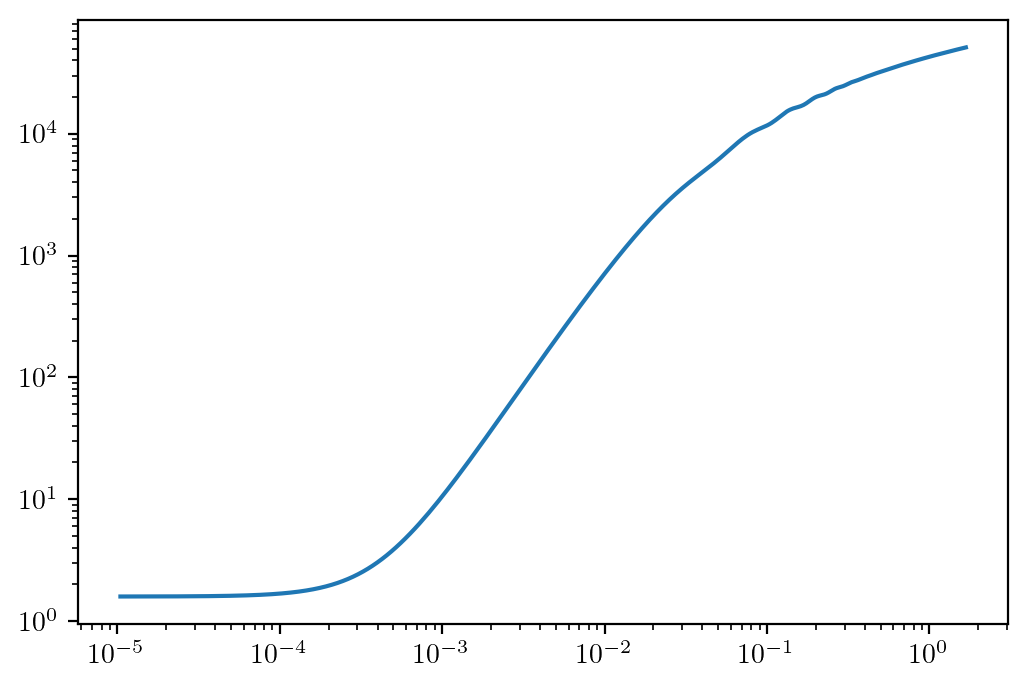

In [25]:
plt.plot(tran['k (h/Mpc)'], np.abs(tran['d_cdm']))
plt.xscale('log')
plt.yscale('log')

In [26]:
klist = np.sort(np.array(common_settings['k_output_values'].split(','), dtype = float))
klist

array([0.001, 0.01 , 0.1  , 1.   ])

Text(0.5, 0, '$a$')

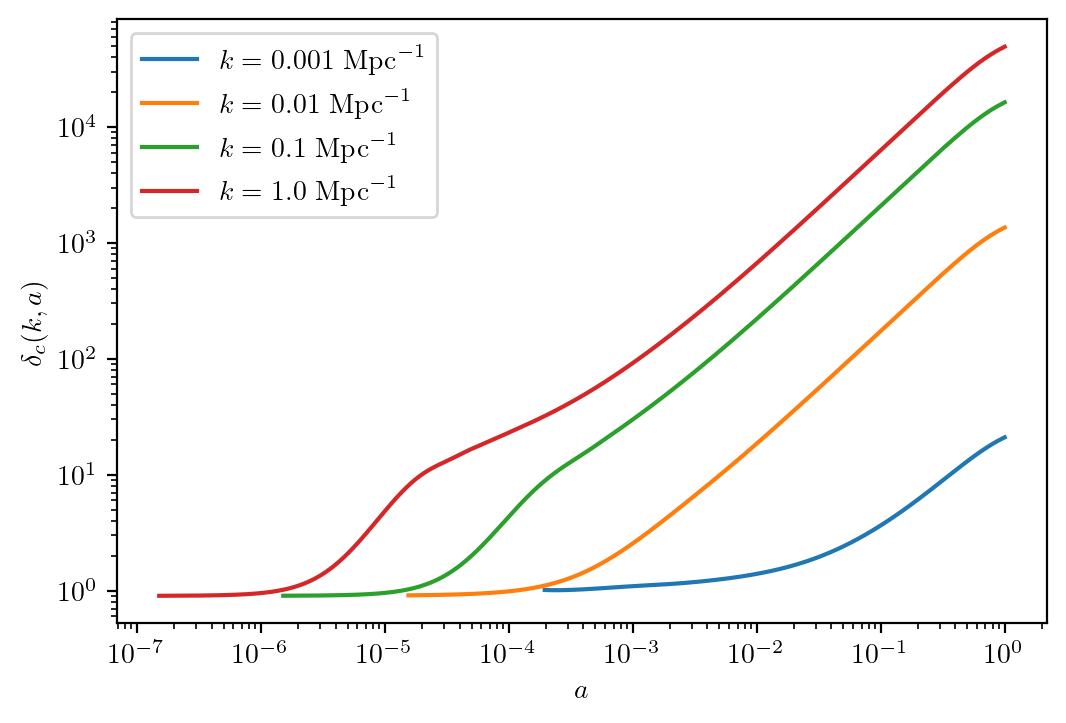

In [27]:

for i, kv in enumerate(klist):
    plt.plot(pert['scalar'][i]['a'],np.abs(pert['scalar'][i]['delta_cdm']), label = fr'$k = {kv} ~{{\rm Mpc}}^{{-1}}$')
plt.xscale('log')
plt.yscale('log')
plt.legend()
plt.ylabel(r'$\delta_c(k,a)$')
plt.xlabel(r'$a$')

(6.887587910269699e-08, 0.001)

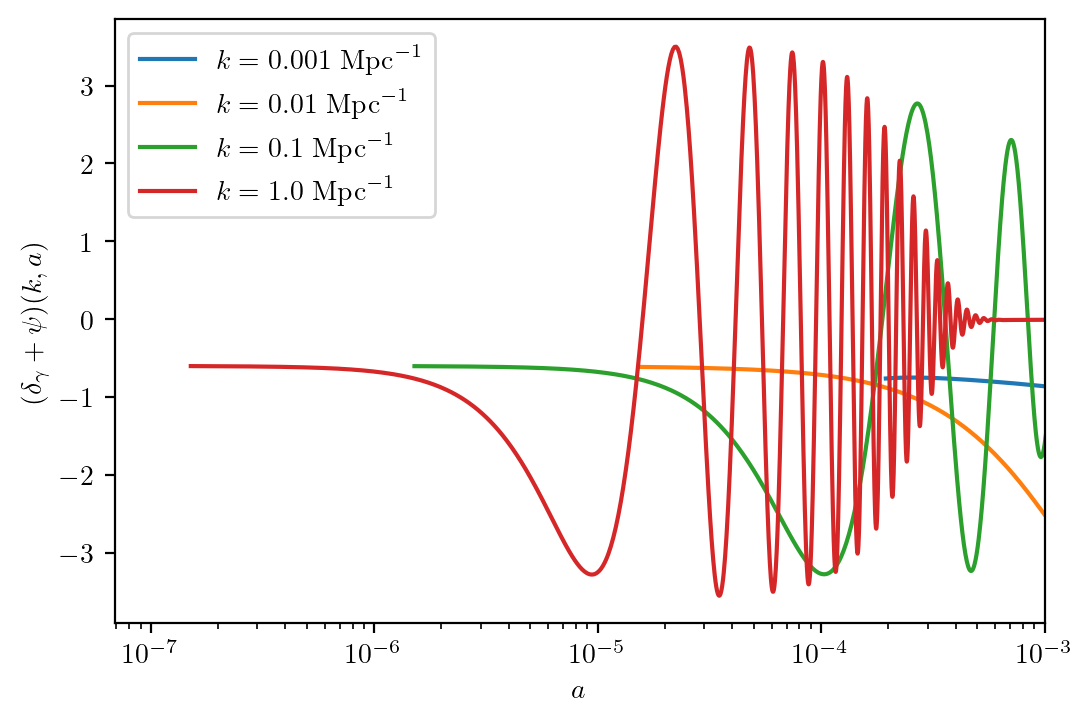

In [28]:
for i, kv in enumerate(klist):
    plt.plot(pert['scalar'][i]['a'],pert['scalar'][i]['delta_g'] +  pert['scalar'][i]['psi'], label = fr'$k = {kv} ~{{\rm Mpc}}^{{-1}}$')
plt.xscale('log')
plt.legend()
plt.ylabel(r'$(\delta_\gamma + \psi)(k,a)$')
plt.xlabel(r'$a$')
plt.xlim([None,1e-3])